# Ekspolartivna analiza podataka - EDA

Skup podataka je preuzet sa: https://www.kaggle.com/datasets/datamunge/sign-language-mnist

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import random as rd

## Ucitavanje podataka

In [2]:
train_df = pd.read_csv("../data/sign_mnist_train.csv")
test_df = pd.read_csv("../data/sign_mnist_test.csv")

In [3]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [5]:
print(f"Trening skup: {train_df.shape[0]} primera, {train_df.shape[1]} kolona")

Trening skup: 27455 primera, 785 kolona


In [6]:
print(f"Test skup: {test_df.shape[0]} primera, {test_df.shape[1]} kolona")

Test skup: 7172 primera, 785 kolona


In [7]:
train_labels = np.sort(train_df["label"].unique())
train_labels

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [8]:
test_labels = np.sort(test_df["label"].unique())
test_labels

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [9]:
(train_labels == test_labels).all()

np.True_

Prva kolona "labels" predstavlja ciljnu promenljivu i odredjuje oznaku klase odnosno znak znakovnog jezika. Skup podataka obuhvata klase od 0 do 24, ali bez 9. A preostale kolone su intenziteti piksela. 

Oznake su slova A-Z (A=0, ..., Z = 25). Slova J (9) i Z (25) su iskljucena iz skupa jer njihovo predstavljanje u znakovnom jeziku zahteva pokret, a skup sadrzi samo staticne snimke ruku.

In [10]:
pixel_columns = [pc for pc in train_df.columns if pc != "label"]

In [11]:
LETTERS = [chr(ord("A") + i) for i in range(26)]
EXCLUDED_LABELS = {9, 25}  # J, Z
LABEL_TO_LETTER = {i: LETTERS[i] for i in range(26) if i not in EXCLUDED_LABELS}
LETTER_TO_LABEL = {v: k for k, v in LABEL_TO_LETTER.items()}

## Slika referentne azbuke

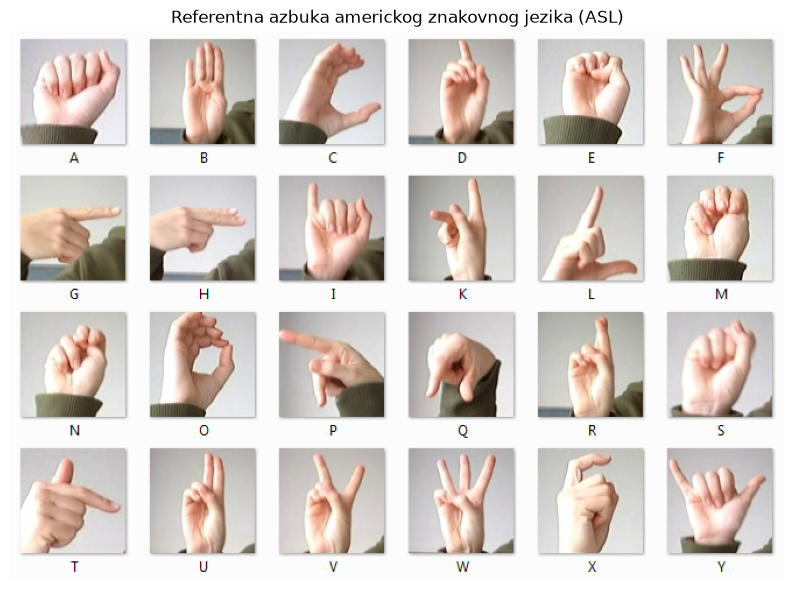

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
ref_img = mpimg.imread("../data/amer_sign2.png")
ax.imshow(ref_img)
ax.axis("off")
ax.set_title("Referentna azbuka americkog znakovnog jezika (ASL)")
plt.show()

## Vizuelno slicna slova

Neka slova se oslanjaju na slicne polozaje sake i prstiju. Ove grupe slova predstavljaju kandidate za najcesce greske modela.
- **M, N, S, E** — pesnica sa palcem ispod različitog broja prstiju
- **U, V, R** — ispruženi kažiprst i srednji prst u različitim konfiguracijama
- **K, P, G** — sličan položaj šake, različita orijentacija
- **G, H** — ispruženi prsti u horizontalnom položaju

## Tipovi podataka i nedostajuce vrednosti

In [13]:
print("Tipovi podataka (trening):")
print(train_df.dtypes.value_counts())

Tipovi podataka (trening):
int64    785
Name: count, dtype: int64


In [14]:
print("\nNedostajuce vrednosti (trening):", train_df.isna().sum().sum())


Nedostajuce vrednosti (trening): 0


In [15]:
print("Nedostajuce vrednosti (test):   ", test_df.isna().sum().sum())

Nedostajuce vrednosti (test):    0


## Duplikati i preklapanje trening i test skupa

In [16]:
train_dupes = train_df.duplicated().sum()
train_dupes

np.int64(0)

In [17]:
test_dupes = test_df.duplicated().sum()
test_dupes

np.int64(0)

In [18]:
train_and_test = pd.concat([train_df, test_df], ignore_index=True)

In [19]:
# duplikati u preklapanju ignorisuci duplikate u test i trening skupu
overlap = train_and_test.duplicated().sum() - (train_dupes + test_dupes)
overlap

np.int64(0)

In [20]:
print(f"Duplikati u trening skupu: {train_dupes}")
print(f"Duplikati u test skupu:    {test_dupes}")
print(f"Redovi koji se poklapaju izmedju trening i test skupa: {overlap}")

Duplikati u trening skupu: 0
Duplikati u test skupu:    0
Redovi koji se poklapaju izmedju trening i test skupa: 0


## Opseg vrednosti piksela

In [21]:
train_min, test_min = train_df[pixel_columns].values.min(), test_df[pixel_columns].values.min()
train_max, test_max = train_df[pixel_columns].values.max(), test_df[pixel_columns].values.max()

In [22]:
print(f"Trening - opseg piksela: [{train_min}, {train_max}]")
print(f"Test - opseg piksela: [{test_min}, {test_max}]")

Trening - opseg piksela: [0, 255]
Test - opseg piksela: [0, 255]


Nema neocekivanih (negativnih ili vecih od 255 vrednosti). Skup treba normalizovati prilikom pripreme podataka.

## Balansiranost klasa

In [23]:
train_counts = train_df["label"].value_counts().sort_index()
train_counts

label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

In [24]:
test_counts = test_df["label"].value_counts().sort_index()
test_counts

label
0     331
1     432
2     310
3     245
4     498
5     247
6     348
7     436
8     288
10    331
11    209
12    394
13    291
14    246
15    347
16    164
17    144
18    246
19    248
20    266
21    346
22    206
23    267
24    332
Name: count, dtype: int64

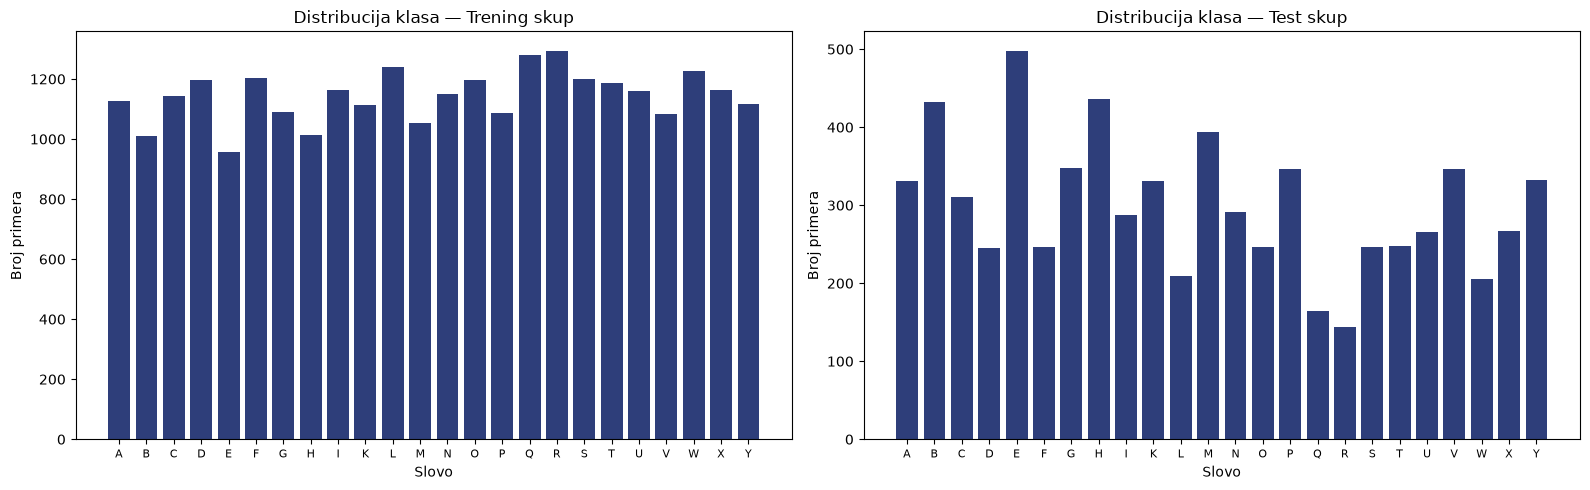

Trening: min-max broj primera po klasi: 957 - 1294
Test: min-max broj primera po klasi: 144 - 498


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counts, title in zip(axes, [train_counts, test_counts], ["Trening skup", "Test skup"]):
    letters = [LABEL_TO_LETTER[i] for i in counts.index]
    ax.bar(letters, counts.values, color="#2e3e7a")
    ax.set_title(f"Distribucija klasa — {title}")
    ax.set_xlabel("Slovo")
    ax.set_ylabel("Broj primera")
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

print(f"Trening: min-max broj primera po klasi: {train_counts.min()} - {train_counts.max()}")
print(f"Test: min-max broj primera po klasi: {test_counts.min()} - {test_counts.max()}")

Trening skup je relativno balansiran. Broj primera po klasi varira u opsegu 950-1300, a test skup je neravnomerniji (140-500). 

## Vizuelni prikaz slicnih slova

In [26]:
similar_groups = [["M", "N", "S", "E"], ["U", "V", "R"], ["K", "P", "G"], ["G", "H"]]

In [27]:
# Prikazuje jednu sliku iz df za dato slovo (A-Y, bez J). 
# index bira koji od svih primera tog slova se prikazuje (0 = prvi u skupu)
def show_letter(letter, df=train_df, index=0):
      label = LETTER_TO_LABEL[letter.upper()]
      row = df[df["label"] == label].iloc[index]
      img = row[pixel_columns].values.astype(np.uint8).reshape(28, 28)

      plt.figure(figsize=(3, 3))
      plt.imshow(img, cmap="gray")
      plt.title(f"Slovo: {letter.upper()}")
      plt.axis("off")
      plt.show()


['M', 'N', 'S', 'E']


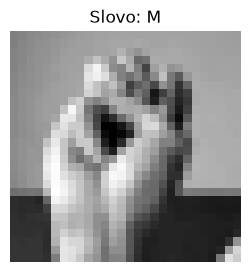

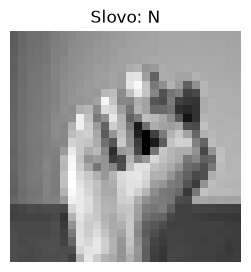

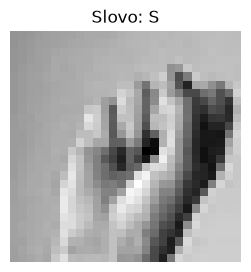

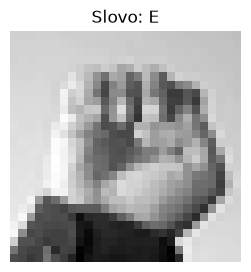

['U', 'V', 'R']


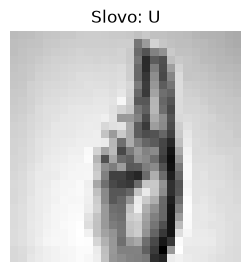

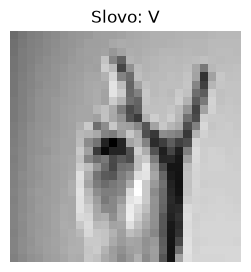

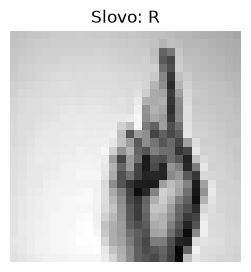

['K', 'P', 'G']


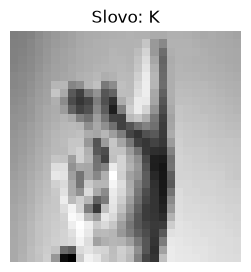

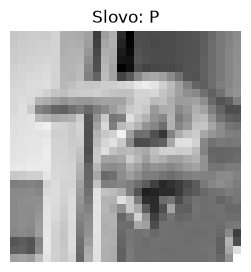

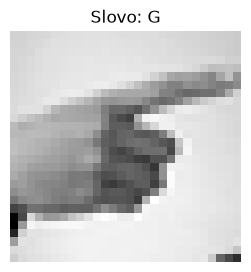

['G', 'H']


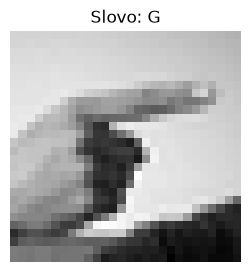

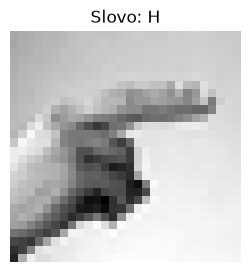

In [28]:
for group in similar_groups: 
    print(group)
    for letter in group:
        show_letter(letter, train_df, rd.randrange(0, 950))